# 02. Neural Network classification with PyTorch

(Date - 27/Apr/2026)

Classification is a problem of predicting whether something is one thing or another.

## 1. Make some classification data and get it ready

In [1]:
import torch
from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from helper_functions import plot_predictions, plot_decision_boundary

In [2]:
n_samples = 1000

X, Y = make_circles(n_samples, noise=0.03, random_state=42)
print(len(X), len(Y), "\n")
print(X[:5], "\n") # Prints the first 5 values of X
print(Y[:5])

1000 1000 

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]] 

[1 1 1 1 0]


In [3]:
circles = pd.DataFrame({"X1" : X[:, 0],
                       "X2" : X[:, 1],
                       "label" : Y} )

circles.head(10)  # prints the first 10 rows of our dataset

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [4]:
circles.label.value_counts() # Counts how many times does each value appear.

label
1    500
0    500
Name: count, dtype: int64

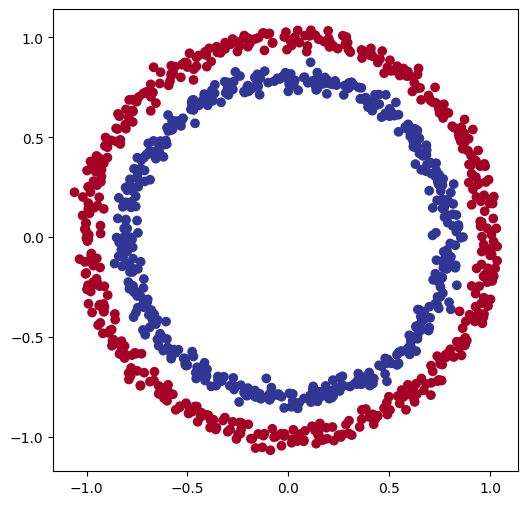

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=Y,
            cmap=plt.cm.RdYlBu);

# You can make the outer dots blue (and the inner dots red) by setting c = 1-Y
# RdYlBu = red -> Yellow -> Blue

### 1.1 Check input and output shapes
(Date - 28/Apr/2026)

In [6]:
X.shape, Y.shape

((1000, 2), (1000,))

In [7]:
# View the first example of feature and labels
X_sample = X[0]
Y_sample = Y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {Y_sample}\n")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {Y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1

Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors  and creating train and test splits

In [8]:
# Turn data into tensors 
X = torch.from_numpy(X).type(torch.float) # torch.float = torch.float32
Y = torch.from_numpy(Y).type(torch.float)

X[:5], Y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [9]:
type(X), type(Y), X.dtype, Y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [10]:
# Splitting data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y,
                                                    test_size = 0.2,#  0.2 = 20% of data will be test and the rest will be for training
                                                    random_state = 42)

In [11]:
len(X_train), len(X_test), len(Y_train), len(Y_test)

(800, 200, 800, 200)

## 2. Building a model

(Date - 29/Apr/2026)

Let's build a model to classify our blue and red dots.

To do so, we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if it's available.
2. Construct a model (by subclassing `nn.module`).
3. define a loss function and an optimizer.
4. Create a training and testing loop.

In [12]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [13]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # Takes in 2 features and upscales to 5 features.
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # Takes in 5 features and outputs 1 feature.

    def forward(self, x):
        return self.layer_2(self.layer_1(x))
    
# Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
# Let's replicate the model above by using nn.sequential
# model_0 = nn.Sequential(
#     nn.Linear(in_features=2, out_features=5),
#     nn.Linear(in_features=5, out_features=1)
# ).to(device)

# model_0

In [15]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.4837,  0.3867],
                      [ 0.4044,  0.6156],
                      [-0.4930, -0.6582],
                      [ 0.5382, -0.4387],
                      [ 0.5162,  0.5198]])),
             ('layer_1.bias',
              tensor([-0.2639,  0.3716, -0.4806, -0.1705,  0.0181])),
             ('layer_2.weight',
              tensor([[-0.2028,  0.0301, -0.2418,  0.2111,  0.3039]])),
             ('layer_2.bias', tensor([0.1967]))])

In [16]:
# Make predictions
with torch.inference_mode():    
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(Y_test)}, Shape: {Y_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 test labels:\n{Y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.]])

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [17]:
total, correct = 0, 0

for i in torch.round(untrained_preds):
    if i == Y_test[total]:
        correct+=1
    total += 1

print(f"Correct predictions: {correct}\nIncorrect predictions: {total}\n")
print(f"{(correct/total)*100}% predictions are correct")

Correct predictions: 96
Incorrect predictions: 200

48.0% predictions are correct


In [18]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.1)

In [19]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    accuracy = (correct / len(y_pred)) * 100 
    return accuracy

## 3. Training our model

(Date - 1/Apr/2026)

<pre>
1. Forward pass - The model goes through all of the training data once, performing its forward() function calculations (model(x_train)).

2. Calculate the loss - The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are (loss = loss_fn(y_pred, y_train).

3. Zero gradients - The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step (optimizer.zero_grad()).

4. Perform backpropagation on the loss - Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with requires_grad=True). This is known as backpropagation, hence "backwards" (loss.backward()).

5. Step the optimizer (gradient descent) - Update the parameters with requires_grad=True with respect to the loss gradients in order to improve them (optimizer.step()).
</pre>

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

logits = raw output of our model without the activation function.

In [20]:
# View the first 5 outputs of the forward pass  on the test data
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]

y_logits

tensor([[0.3455],
        [0.5097],
        [0.0818],
        [0.4195],
        [0.3469]])

In [21]:
Y_test[:5] # The format of y_logits is different from the format of our Y_test, i.e. Y_test contains 0s and 1s, while y_logits contains some non-sense values, which look random.

tensor([1., 0., 1., 0., 1.])

In [22]:
# Using a sigmoid activation function on our model logits to turn them into prediction probabilities.
Y_pred_probs = torch.sigmoid(y_logits)
Y_pred_probs

tensor([[0.5855],
        [0.6247],
        [0.5204],
        [0.6034],
        [0.5859]])

For our prediction probability values, we need to perform a range-style rounding on them:

* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` < 0.5, `y=1` (class 0)


In [23]:
Y_preds = torch.round(Y_pred_probs) # Now the formats are same, i.e. 0s and 1s!

# In full
Y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Making sure that Y_preds == Y_pred_labels
print(torch.eq(Y_preds.squeeze(), Y_pred_labels.squeeze()))

# Getting rid of extra dimensions
Y_preds.squeeze() # This function is just for demonstration. It has no extra role in our project.

# Note :-
# Y_preds and Y_pred_labels are exactly same. We just created the Y_preds step by step, while the Y_pred_labels is created in just one line. Y_preds is easier to understand, like what's going on.

tensor([True, True, True, True, True])


tensor([1., 1., 1., 1., 1.])

### 3.2 Building a training and testing loop

In [24]:
torch.manual_seed(7)

# Set the number of epochs
epochs = 100

# Put data to the target device
X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test, Y_test = X_test.to(device), Y_test.to(device)

# Building a training and evaluating loop
for epoch in range(epochs):
    ### Training

    model_0.train()

    Y_logits = model_0(X_train).squeeze()
    Y_pred = torch.round(torch.sigmoid(Y_logits))

    # loss = loss_fn(torch.sigmoid(Y_logits))
    loss = loss_fn(Y_logits, 
                   Y_train)

    acc = accuracy_fn(y_true=Y_train,
                      y_pred=Y_pred)
    
    optimizer.zero_grad()

    loss.backward() # backpropagation

    optimizer.step() # Gradient descent



    ### Testing
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits,
                            Y_test)
        
        test_acc = accuracy_fn(y_true = Y_test,
                               y_pred = test_pred)
        
    if epoch % 10 == 0:
         print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71210, Accuracy: 51.38% | Test loss: 0.72004, Test acc: 53.50%


Epoch: 10 | Loss: 0.70176, Accuracy: 59.38% | Test loss: 0.70736, Test acc: 58.00%
Epoch: 20 | Loss: 0.69740, Accuracy: 54.37% | Test loss: 0.70146, Test acc: 50.00%
Epoch: 30 | Loss: 0.69550, Accuracy: 52.75% | Test loss: 0.69854, Test acc: 48.50%
Epoch: 40 | Loss: 0.69461, Accuracy: 52.25% | Test loss: 0.69698, Test acc: 49.50%
Epoch: 50 | Loss: 0.69417, Accuracy: 51.25% | Test loss: 0.69609, Test acc: 50.00%
Epoch: 60 | Loss: 0.69392, Accuracy: 51.50% | Test loss: 0.69555, Test acc: 51.00%
Epoch: 70 | Loss: 0.69376, Accuracy: 50.12% | Test loss: 0.69520, Test acc: 50.50%
Epoch: 80 | Loss: 0.69365, Accuracy: 50.50% | Test loss: 0.69496, Test acc: 51.50%
Epoch: 90 | Loss: 0.69356, Accuracy: 50.62% | Test loss: 0.69479, Test acc: 51.50%


## 4. Making predictions and evaluating the model

From the matrics, it looks like our model isn't learning anything... 

Let's fix that!


In [25]:
# Download helper functions from Learn PyTorch repo (if not already downloaded)

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")

else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

# from helper_functions import plot_predictions, plot_decision_boundary -> We have imported these at the top of the notebook.

helper_functions.py already exists, skipping download


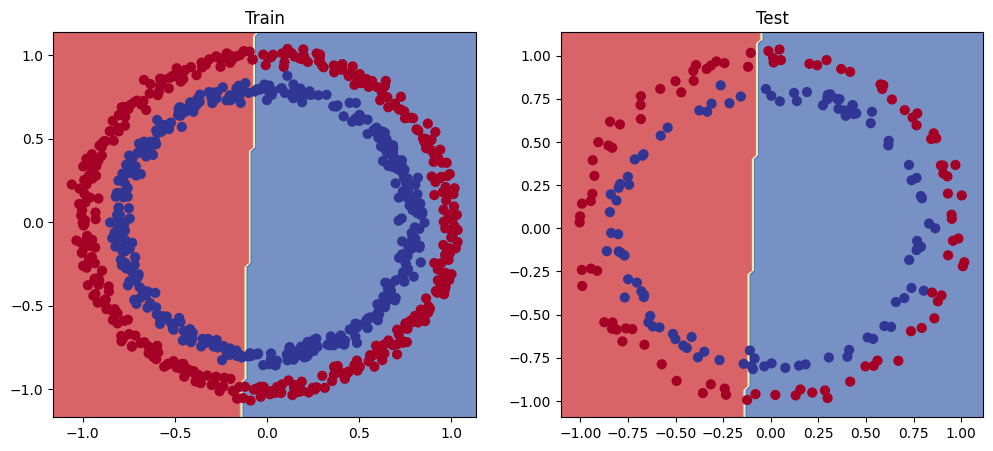

In [26]:
# plot decision boundary of the model

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, Y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, Y_test)
          

## 5. Improving our model (from model's perspective)

(Date - 2/Apr/2026)

* Add more layers - Give the model more chances to learn about patterns in the data.
* Add more hidden units - go from 5 hidden units to 10 hidden units.
* Fit for longer - Increase epochs.
* Changing the activation functions.
* Change the learning rate.
* Change the loss function.

Let's try and improve our model by:
* Adding more hidden units : 5->10
* Increase the number of layers : 2->3
* Increase the number of epochs : 100-> 1000

In [27]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
    
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x))) 

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [28]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.0494, -0.4260],
                      [ 0.2252,  0.2219],
                      [-0.3779, -0.1060],
                      [-0.4142,  0.1835],
                      [-0.1905,  0.4968],
                      [ 0.5020,  0.0720],
                      [-0.3015, -0.4153],
                      [-0.0777, -0.1990],
                      [ 0.3117, -0.6038],
                      [ 0.6646, -0.5547]])),
             ('layer_1.bias',
              tensor([ 0.5415, -0.1228,  0.3637,  0.2756,  0.0296,  0.1318,  0.5370,  0.1819,
                       0.3752, -0.5470])),
             ('layer_2.weight',
              tensor([[ 0.2251,  0.1088,  0.0801,  0.0437,  0.1542,  0.2904, -0.0704, -0.1762,
                       -0.0796, -0.1927],
                      [ 0.1521, -0.1563, -0.1688,  0.2729,  0.2894,  0.0364, -0.0548, -0.0408,
                        0.1498, -0.2953],
                      [-0.2584,  0.2526,  0.3122, -0.0188, -0.2499,  0.0

In [29]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr = 0.1)

In [30]:
torch.manual_seed(42)

epochs = 1000

X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test, Y_test = X_test.to(device), Y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    Y_logits = model_1(X_train).squeeze()
    Y_pred = torch.round(torch.sigmoid(Y_logits))

    loss = loss_fn(Y_logits, Y_train)
    acc = accuracy_fn(y_pred=Y_pred,
                      y_true=Y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, Y_test)

        test_acc = accuracy_fn(y_true=Y_test,
                               y_pred = test_pred)
    
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.70510, Accuracy: 46.88% | Test loss: 0.70741, Test acc: 43.50%
Epoch: 100 | Loss: 0.69358, Accuracy: 50.12% | Test loss: 0.69571, Test acc: 49.50%
Epoch: 200 | Loss: 0.69314, Accuracy: 50.50% | Test loss: 0.69467, Test acc: 48.50%
Epoch: 300 | Loss: 0.69304, Accuracy: 50.50% | Test loss: 0.69439, Test acc: 47.50%
Epoch: 400 | Loss: 0.69301, Accuracy: 51.00% | Test loss: 0.69434, Test acc: 45.50%
Epoch: 500 | Loss: 0.69299, Accuracy: 50.62% | Test loss: 0.69436, Test acc: 47.50%
Epoch: 600 | Loss: 0.69299, Accuracy: 50.62% | Test loss: 0.69441, Test acc: 47.00%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.62% | Test loss: 0.69446, Test acc: 47.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.12% | Test loss: 0.69450, Test acc: 46.50%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test loss: 0.69454, Test acc: 46.00%


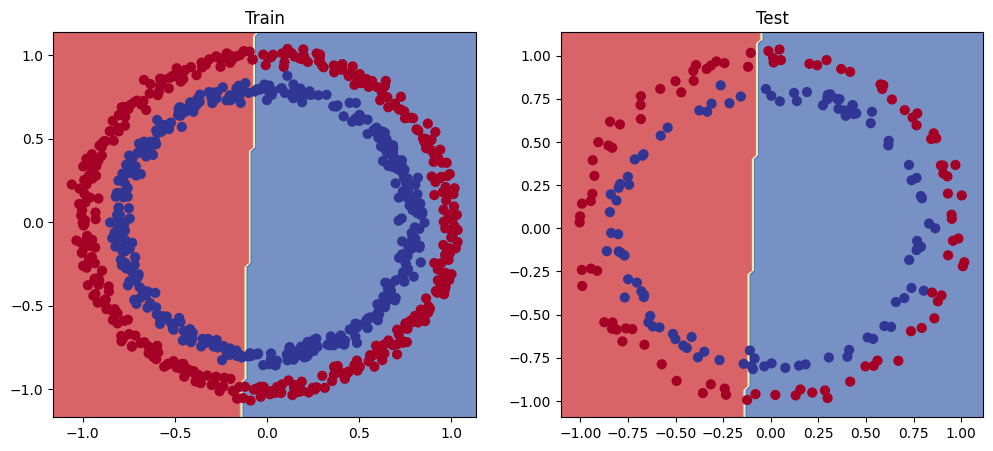

In [31]:
# Plot the decision boundary

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, Y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, Y_test)

In [32]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [33]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


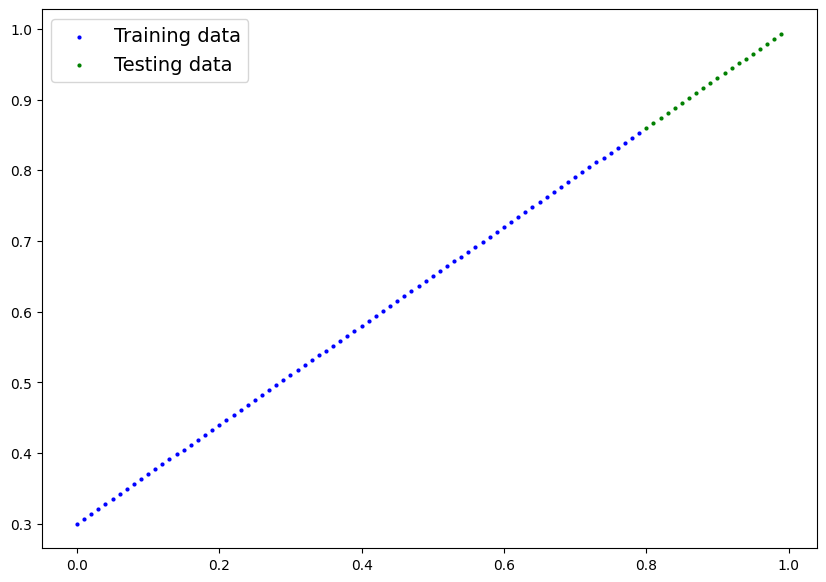

In [34]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

In [35]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [36]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.001)

In [37]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training 
    # 1. Forward pass
    y_pred = model_2(X_train_regression)
    
    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss 
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0: 
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75986, Test loss: 0.94965
Epoch: 100 | Train loss: 0.40272, Test loss: 0.54029
Epoch: 200 | Train loss: 0.05876, Test loss: 0.13480
Epoch: 300 | Train loss: 0.01461, Test loss: 0.03342
Epoch: 400 | Train loss: 0.00308, Test loss: 0.00008
Epoch: 500 | Train loss: 0.00309, Test loss: 0.00012
Epoch: 600 | Train loss: 0.00309, Test loss: 0.00018
Epoch: 700 | Train loss: 0.00299, Test loss: 0.00011
Epoch: 800 | Train loss: 0.00299, Test loss: 0.00016
Epoch: 900 | Train loss: 0.00289, Test loss: 0.00011


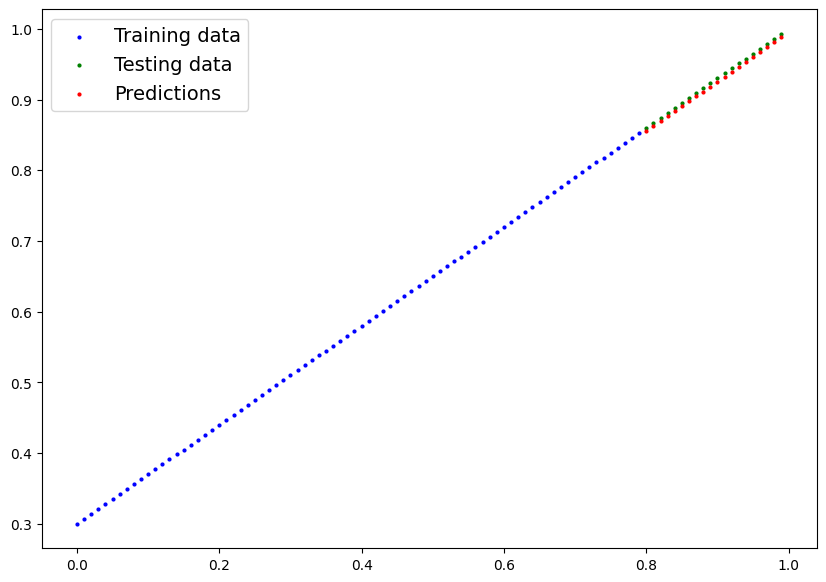

In [38]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

Hmm... Our model is making great predictions! But in a linear case... What can we do to make it better for non-linear cases? Let's solve this issue in the next file (24.ipynb)